# Predicting Student Health Risk

## Exploratory Data Analysis

This notebook explores the training dataset using statistical summaries and visualisations. The purpose is to understand the data distribution, target balance, missing values, outliers, categorical values, and relationships between features.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("Libraries imported successfully")

Libraries imported successfully


In [28]:
current_folder = Path.cwd()

if (current_folder / "data").exists():
    project_folder = current_folder
else:
    project_folder = current_folder.parent

data_folder = project_folder / "data" / "kaggle" / "raw"

print("Project folder")
print(project_folder)

print()

print("Data folder")
print(data_folder)

Project folder
c:\Users\Admin\Documents\Rakindu's Files\ICBT\Computational Intelligence\Assignment\Student health risk project

Data folder
c:\Users\Admin\Documents\Rakindu's Files\ICBT\Computational Intelligence\Assignment\Student health risk project\data\kaggle\raw


In [29]:
train_file = data_folder / "train.csv"
test_file = data_folder / "test.csv"

train_data = pd.read_csv(train_file)
test_data = pd.read_csv(test_file)

print("Training data loaded successfully")
print("Testing data loaded successfully")

Training data loaded successfully
Testing data loaded successfully


In [30]:
print("Training dataset shape")
print(train_data.shape)

print()

print("Testing dataset shape")
print(test_data.shape)

Training dataset shape
(690088, 15)

Testing dataset shape
(295753, 14)


In [31]:
target_column = "health_condition"

print("Target column")
print(target_column)

Target column
health_condition


In [32]:
target_counts = train_data[target_column].value_counts()

print("Target class counts")
print(target_counts)

Target class counts
health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64


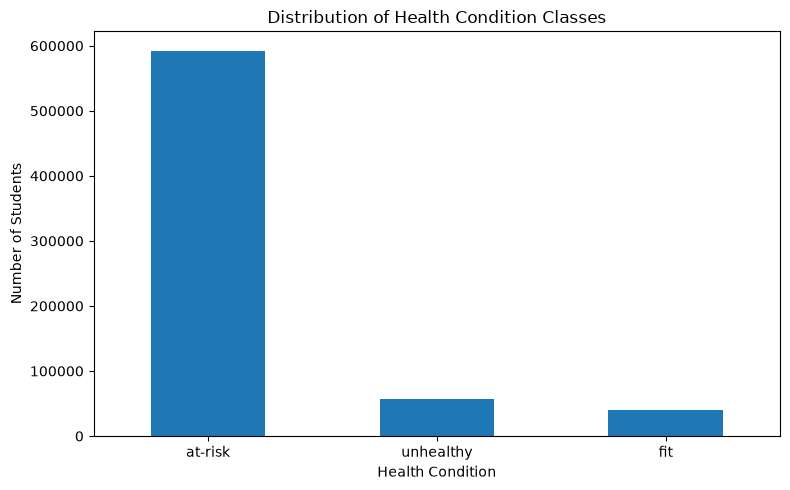

In [33]:
target_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Distribution of Health Condition Classes")
plt.xlabel("Health Condition")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [34]:
target_percentages = (
    train_data[target_column]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Target class percentages")
print(target_percentages)

Target class percentages
health_condition
at-risk      85.87
unhealthy     8.36
fit           5.77
Name: proportion, dtype: float64


In [35]:
missing_values = train_data.isnull().sum()

missing_values = missing_values[
    missing_values > 0
].sort_values(ascending=False)

print("Columns containing missing values")
print(missing_values)

Columns containing missing values
stress_level               82811
sleep_duration             75999
sleep_quality              58331
calorie_expenditure        52853
water_intake               43477
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
step_count                 13916
bmi                        13898
heart_rate                  7833
diet_type                   6901
exercise_duration           6901
dtype: int64


In [36]:
missing_percentages = (
    train_data.isnull()
    .mean()
    .mul(100)
)

missing_percentages = missing_percentages[
    missing_percentages > 0
].sort_values(ascending=False)

print("Missing-value percentages")
print(missing_percentages.round(2))

Missing-value percentages
stress_level               12.00
sleep_duration             11.01
sleep_quality               8.45
calorie_expenditure         7.66
water_intake                6.30
physical_activity_level     5.31
smoking_alcohol             4.14
gender                      3.10
step_count                  2.02
bmi                         2.01
heart_rate                  1.14
diet_type                   1.00
exercise_duration           1.00
dtype: float64


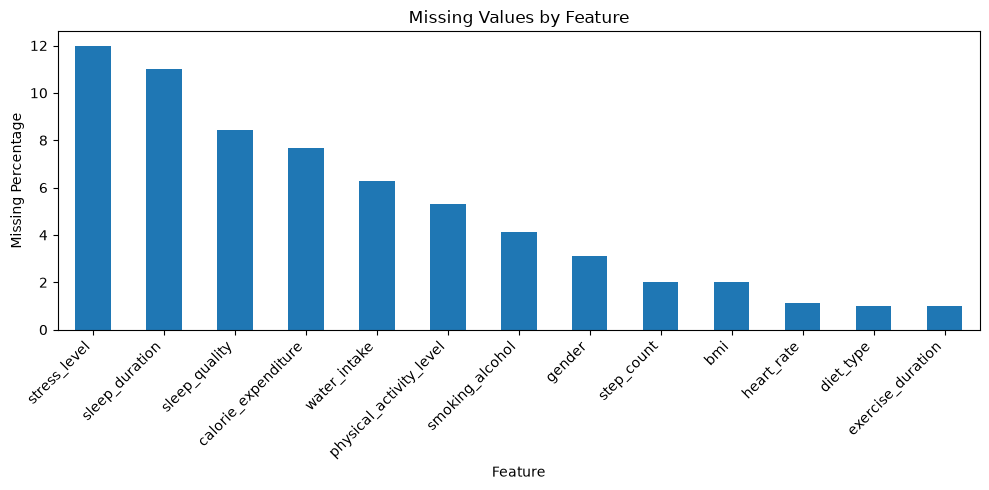

In [37]:
if len(missing_percentages) > 0:
    missing_percentages.plot(
        kind="bar",
        figsize=(10, 5)
    )

    plt.title("Missing Values by Feature")
    plt.xlabel("Feature")
    plt.ylabel("Missing Percentage")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("The training dataset does not contain missing values")

In [38]:
numerical_columns = train_data.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Numerical columns")
print(numerical_columns)

print()

print("Number of numerical columns")
print(len(numerical_columns))

Numerical columns
['id', 'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']

Number of numerical columns
8


In [39]:
numerical_summary = train_data[numerical_columns].describe().T

numerical_summary

,count,mean,std,min,25%,50%,75%,max
id,690088.0,345043.500000,199211.390620,0.0,172521.75,345043.50,517565.25,690087.00
sleep_duration,614089.0,6.992597,1.215407,3.0,6.16,6.99,7.81,10.00
heart_rate,682255.0,75.096504,8.175106,50.0,69.40,75.10,80.70,107.70
bmi,676190.0,22.984925,2.481787,16.0,21.32,22.99,24.66,34.82
calorie_expenditure,637235.0,2226.084931,347.532098,1200.0,2053.00,2241.00,2456.00,3580.00
step_count,676172.0,8615.953050,3929.399831,1002.0,5389.00,8856.00,12114.00,14999.00
exercise_duration,683187.0,38.751456,14.742189,0.0,29.20,39.40,49.40,99.80
water_intake,646611.0,2.188542,0.518489,0.5,1.84,2.17,2.50,4.72


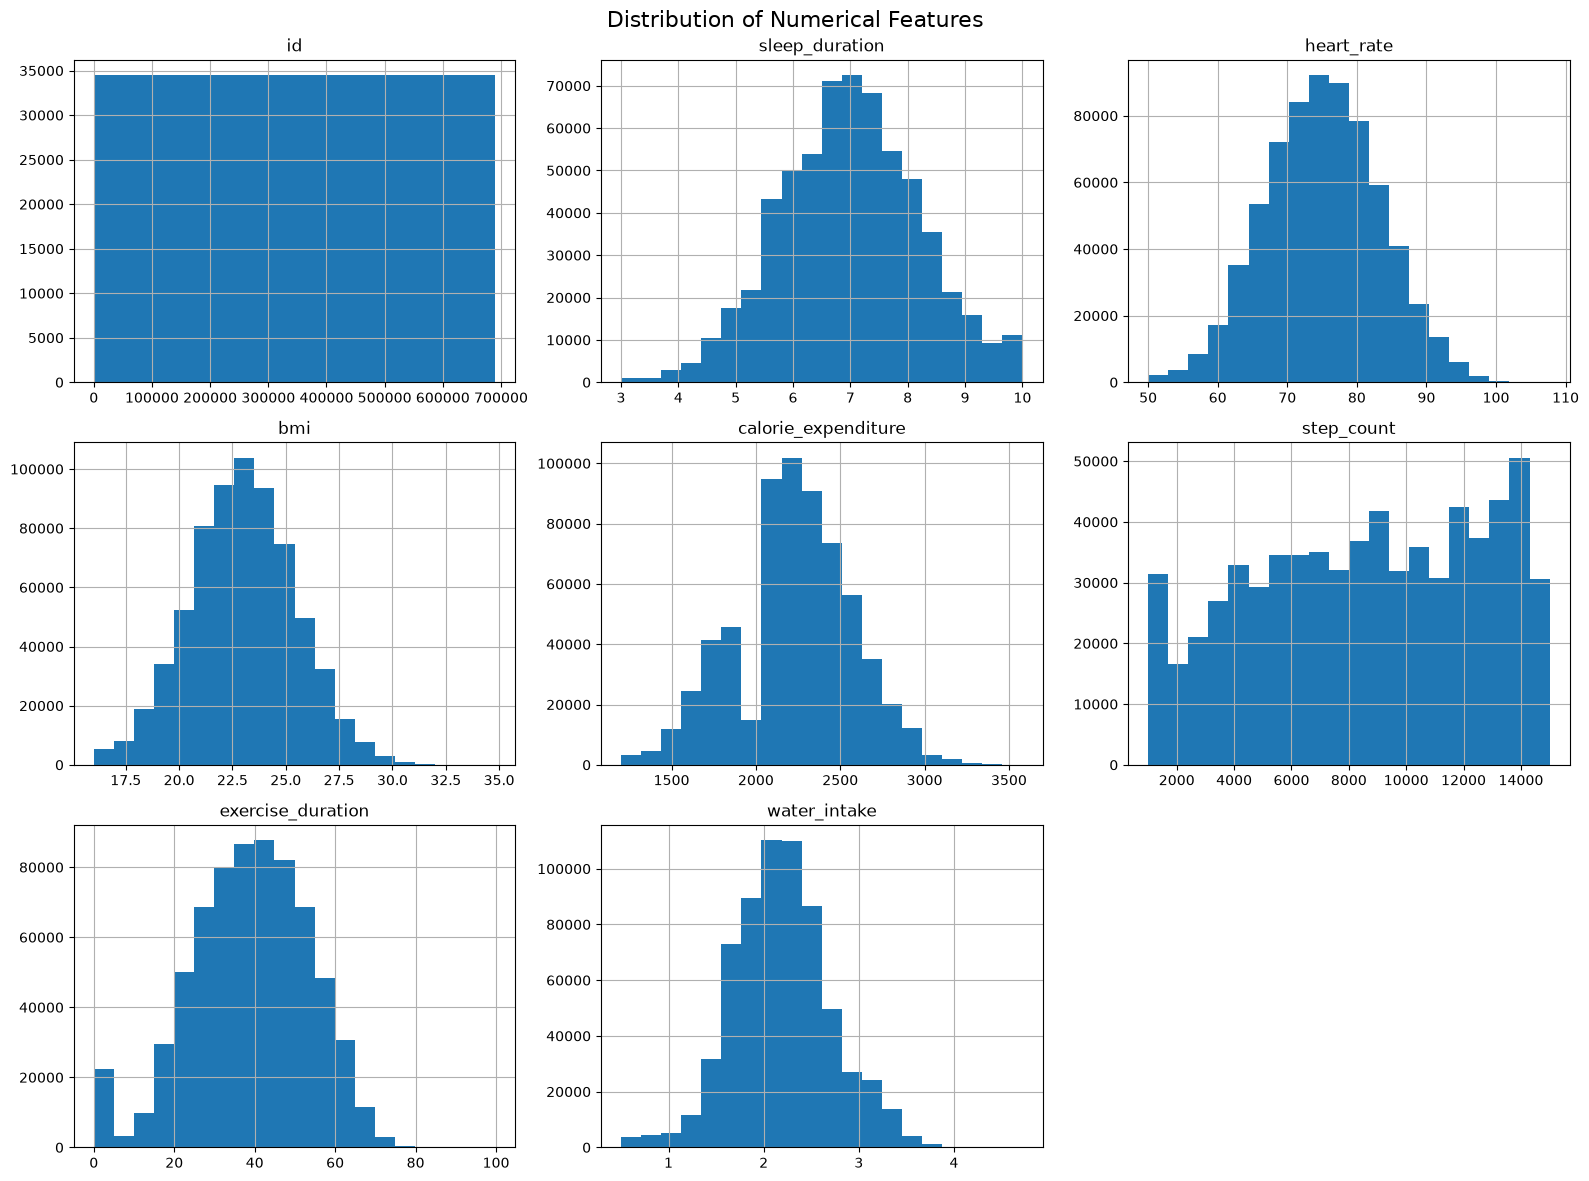

In [40]:
train_data[numerical_columns].hist(
    figsize=(16, 12),
    bins=20
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

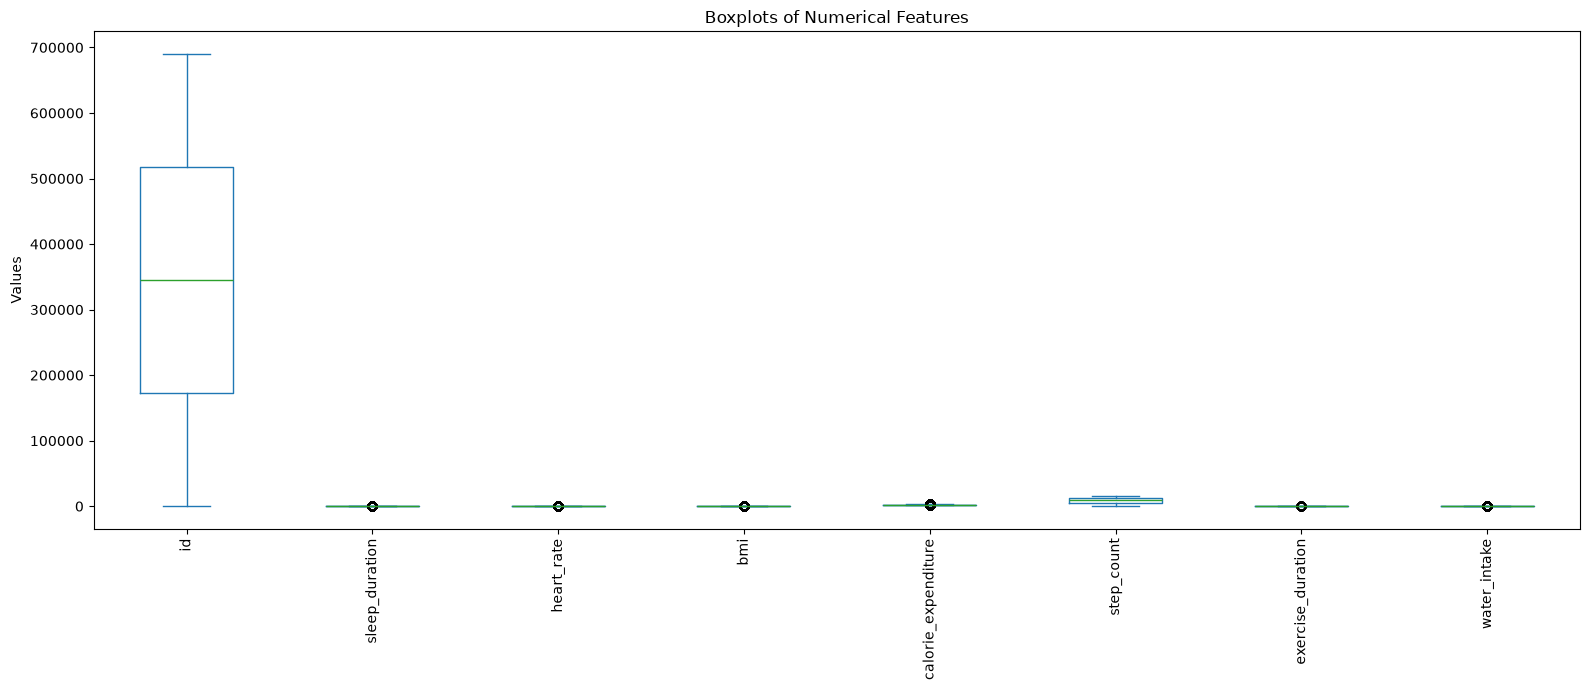

In [41]:
train_data[numerical_columns].plot(
    kind="box",
    figsize=(16, 7),
    rot=90
)

plt.title("Boxplots of Numerical Features")
plt.ylabel("Values")
plt.tight_layout()
plt.show()

In [42]:
correlation_matrix = train_data[
    numerical_columns
].corr()

correlation_matrix

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
id,1.000000,-0.001340,-0.001008,-0.000095,-0.000917,0.000155,-0.000883,0.001147
sleep_duration,-0.001340,1.000000,-0.005183,-0.074576,-0.004075,0.004082,0.001708,0.000519
heart_rate,-0.001008,-0.005183,1.000000,0.000612,-0.003967,-0.005486,-0.005679,0.000192
bmi,-0.000095,-0.074576,0.000612,1.000000,0.117624,-0.020548,-0.020289,0.000638
calorie_expenditure,-0.000917,-0.004075,-0.003967,0.117624,1.000000,0.400102,0.393592,0.001534
step_count,0.000155,0.004082,-0.005486,-0.020548,0.400102,1.000000,0.438236,-0.000588
exercise_duration,-0.000883,0.001708,-0.005679,-0.020289,0.393592,0.438236,1.000000,0.002199
water_intake,0.001147,0.000519,0.000192,0.000638,0.001534,-0.000588,0.002199,1.000000


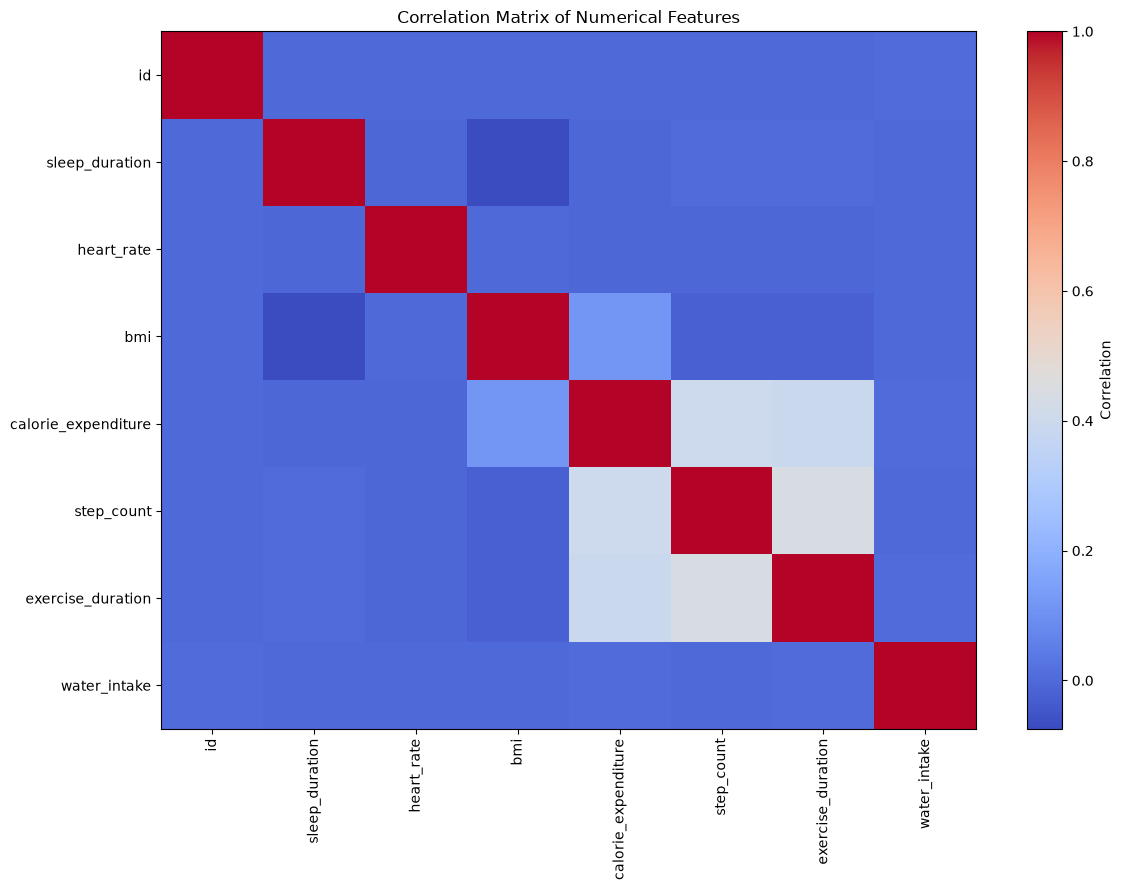

In [43]:
plt.figure(figsize=(12, 9))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

In [44]:
categorical_columns = train_data.select_dtypes(
    include=["object", "category"]
).columns.tolist()

categorical_feature_columns = categorical_columns.copy()

if target_column in categorical_feature_columns:
    categorical_feature_columns.remove(target_column)

print("Categorical feature columns")
print(categorical_feature_columns)

print()

print("Number of categorical features")
print(len(categorical_feature_columns))

Categorical feature columns
['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']

Number of categorical features
6


C:\Users\Admin\AppData\Local\Temp\ipykernel_31224\1321732898.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = train_data.select_dtypes(


In [45]:
categorical_unique_counts = train_data[
    categorical_feature_columns
].nunique().sort_values()

print("Number of unique values in categorical features")
print(categorical_unique_counts)

Number of unique values in categorical features
diet_type                  3
stress_level               3
sleep_quality              3
physical_activity_level    3
smoking_alcohol            3
gender                     3
dtype: int64


In [46]:
train_data[
    categorical_feature_columns
].describe().T

,count,unique,top,freq
diet_type,683187,3,veg,231432
stress_level,607277,3,medium,261819
sleep_quality,631757,3,average,213948
physical_activity_level,653467,3,moderate,221041
smoking_alcohol,661506,3,yes,223730
gender,668715,3,male,237756


In [47]:
for column in categorical_feature_columns:
    print()
    print("Feature")
    print(column)

    print(
        train_data[column]
        .value_counts(dropna=False)
    )


Feature
diet_type
diet_type
veg         231432
balanced    226888
non-veg     224867
NaN           6901
Name: count, dtype: int64

Feature
stress_level
stress_level
medium    261819
high      177750
low       167708
NaN        82811
Name: count, dtype: int64

Feature
sleep_quality
sleep_quality
average    213948
poor       212166
good       205643
NaN         58331
Name: count, dtype: int64

Feature
physical_activity_level
physical_activity_level
moderate     221041
sedentary    219784
active       212642
NaN           36621
Name: count, dtype: int64

Feature
smoking_alcohol
smoking_alcohol
yes           223730
no            219791
occasional    217985
NaN            28582
Name: count, dtype: int64

Feature
gender
gender
male      237756
female    224016
other     206943
NaN        21373
Name: count, dtype: int64


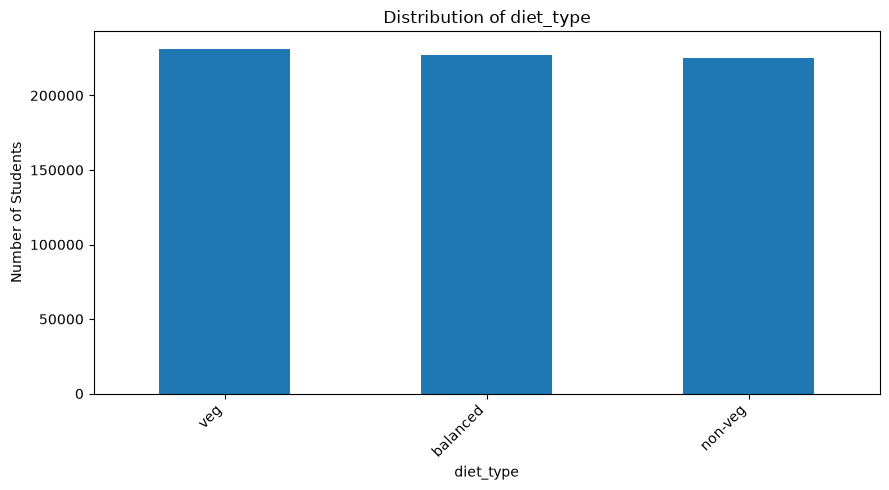

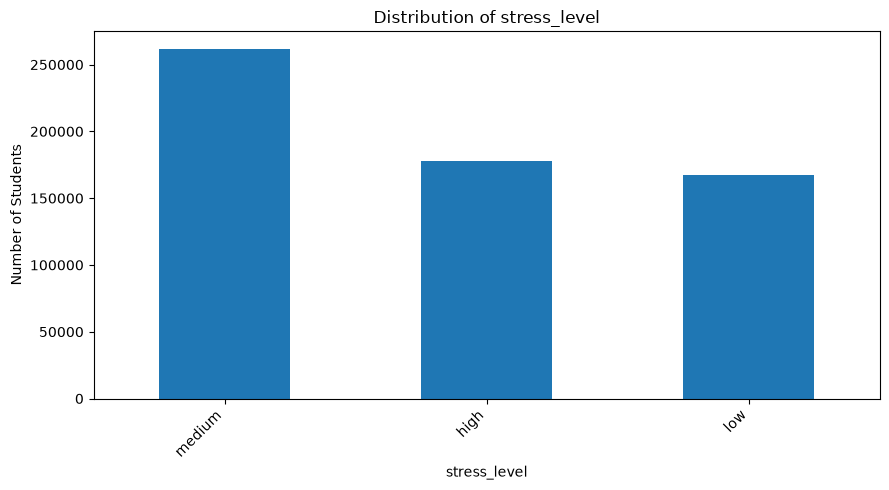

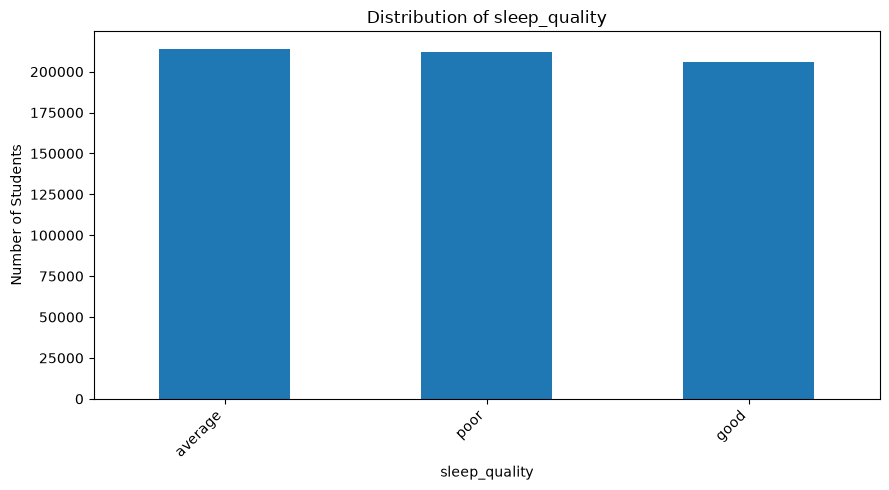

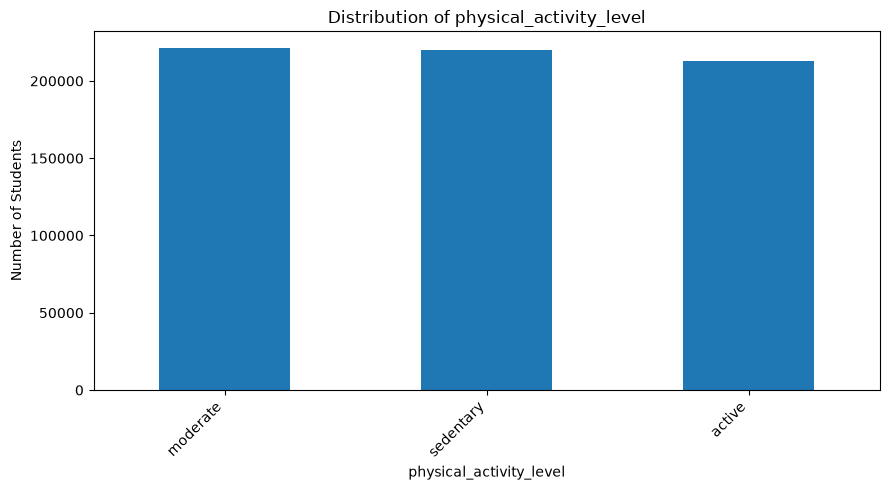

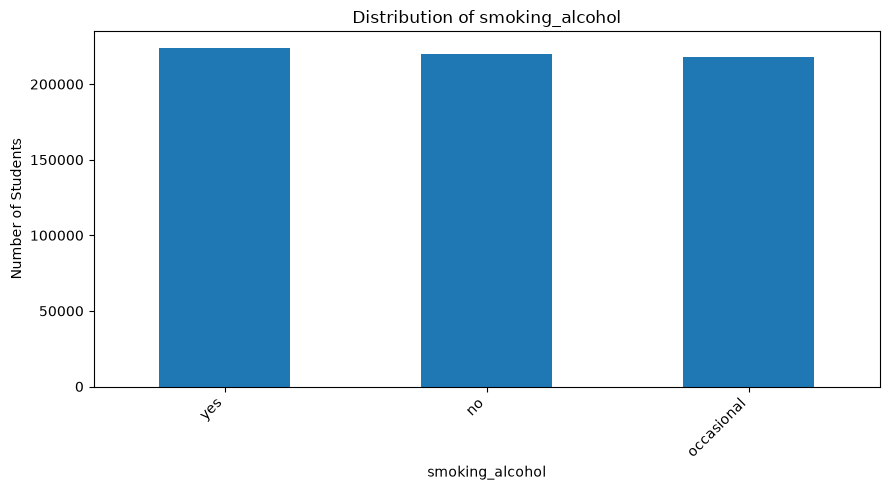

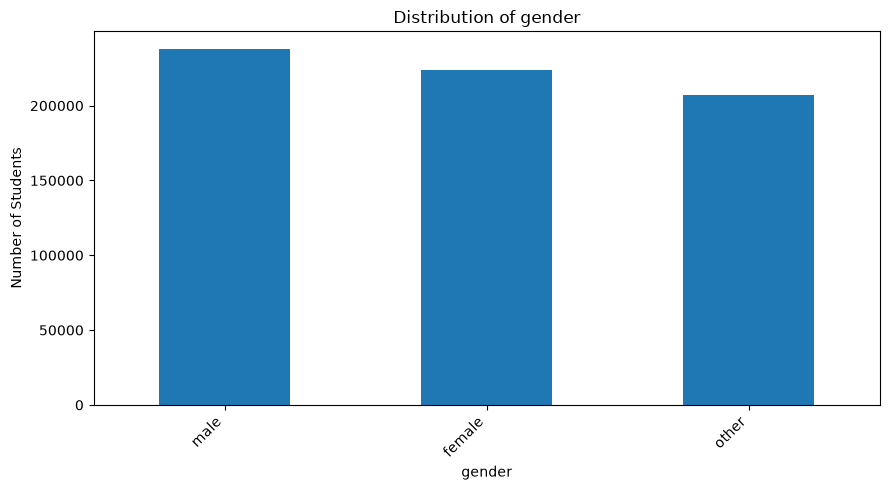

In [48]:
for column in categorical_feature_columns:
    value_counts = train_data[column].value_counts().head(15)

    value_counts.plot(
        kind="bar",
        figsize=(9, 5)
    )

    plt.title("Distribution of " + column)
    plt.xlabel(column)
    plt.ylabel("Number of Students")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [49]:
grouped_numerical_means = train_data.groupby(
    target_column
)[numerical_columns].mean()

grouped_numerical_means.T

health_condition,at-risk,fit,unhealthy
id,345133.986197,344537.856091,344463.282985
sleep_duration,7.086467,7.954311,5.366118
heart_rate,75.100534,74.803742,75.256903
bmi,22.949591,21.828544,24.122660
calorie_expenditure,2214.943466,2363.992052,2245.420223
step_count,8406.705910,11651.307024,8670.234090
exercise_duration,37.964960,50.042381,39.044280
water_intake,2.189130,2.179176,2.188961


In [50]:
for column in categorical_feature_columns:
    relationship_table = pd.crosstab(
        train_data[column],
        train_data[target_column],
        normalize="index"
    ).mul(100).round(2)

    print()
    print("Relationship between")
    print(column)
    print("and")
    print(target_column)

    print(relationship_table)


Relationship between
diet_type
and
health_condition
health_condition  at-risk   fit  unhealthy
diet_type                                 
balanced            85.14  6.12       8.74
non-veg             86.78  5.16       8.06
veg                 85.67  6.04       8.30

Relationship between
stress_level
and
health_condition
health_condition  at-risk    fit  unhealthy
stress_level                               
high                71.78   0.35      27.87
low                 79.67  20.06       0.28
medium              99.39   0.30       0.31

Relationship between
sleep_quality
and
health_condition
health_condition  at-risk   fit  unhealthy
sleep_quality                             
average             85.93  5.73       8.34
good                88.78  8.17       3.05
poor                82.96  3.46      13.58

Relationship between
physical_activity_level
and
health_condition
health_condition         at-risk    fit  unhealthy
physical_activity_level                           
active         

In [51]:
unique_ratios = (
    train_data.nunique()
    .div(len(train_data))
    .sort_values(ascending=False)
)

possible_identifier_columns = unique_ratios[
    unique_ratios > 0.95
]

print("Possible identifier columns")
print(possible_identifier_columns)

Possible identifier columns
id    1.0
dtype: float64


In [52]:
duplicate_count = train_data.duplicated().sum()

print("Number of duplicated training records")
print(duplicate_count)

Number of duplicated training records
0


## Main EDA findings

The training dataset contains 690,088 rows and 15 columns.

The largest target class is `at-risk` with 592,561 records, while the smallest class is `fit` with 39,803 records.

The dataset contains 449,496 missing values. The highest missing percentages were found in `stress_level` at 12.00 percent, `sleep_duration` at 11.01 percent, and `sleep_quality` at 8.45 percent.

No duplicated rows were found.

Possible outliers were visible in `sleep_duration`, `heart_rate`, `bmi`, `calorie_expenditure`, `step_count`, `exercise_duration`, and `water_intake`. These values were kept because they may be genuine records.

The strongest numerical relationships were between `step_count` and `exercise_duration` at 0.438, `calorie_expenditure` and `step_count` at 0.400, and `calorie_expenditure` and `exercise_duration` at 0.394.

The features that showed clear relationships with the target were `stress_level`, `physical_activity_level`, `sleep_quality`, `smoking_alcohol`, `sleep_duration`, `bmi`, and `step_count`.

The `id` column was identified as an identifier because every value was unique.

Based on the EDA, the preprocessing stage should remove `id`, handle missing values, encode categorical features, scale numerical features, use stratified splitting, and handle class imbalance.